In [1]:
import numpy as np
import pandas as pd

In [2]:
data=pd.read_csv(r"C:\Users\ASUS\Downloads\archive (8)\Mall_Customers.csv")

In [3]:
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:

data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
data.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
data.shape

(200, 5)

In [7]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
data=data.drop("CustomerID",axis=1)

In [9]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data["Gender"]=le.fit_transform(data["Gender"])

In [10]:
data

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
195,0,35,120,79
196,0,45,126,28
197,1,32,126,74
198,1,32,137,18


In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

In [16]:
scaled_data

array([[ 1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [ 1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [-0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [-0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [-0.88640526, -0.56336851, -1.66266033, -0.39597992],
       [-0.88640526, -1.20926872, -1.66266033,  1.00159627],
       [-0.88640526, -0.27630176, -1.62449091, -1.71591298],
       [-0.88640526, -1.13750203, -1.62449091,  1.70038436],
       [ 1.12815215,  1.80493225, -1.58632148, -1.83237767],
       [-0.88640526, -0.6351352 , -1.58632148,  0.84631002],
       [ 1.12815215,  2.02023231, -1.58632148, -1.4053405 ],
       [-0.88640526, -0.27630176, -1.58632148,  1.89449216],
       [-0.88640526,  1.37433211, -1.54815205, -1.36651894],
       [-0.88640526, -1.06573534, -1.54815205,  1.04041783],
       [ 1.12815215, -0.13276838, -1.54815205, -1.44416206],
       [ 1.12815215, -1.20926872, -1.54815205,  1.11806095],
       [-0.88640526, -0.

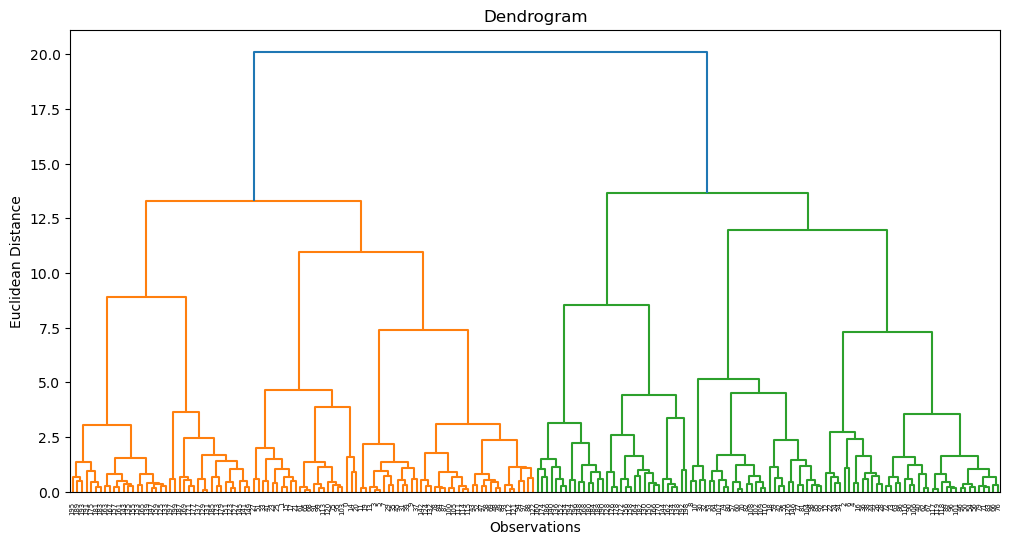

In [19]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
linked = linkage(scaled_data, method='ward')

plt.figure(figsize=(12,6))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Euclidean Distance")
plt.show()

In [22]:

from sklearn.decomposition import PCA   
pca = PCA(n_components = 2)
X_principal_5 = pca.fit_transform(scaled_data)
X_principal_5 = pd.DataFrame(X_principal_5)
X_principal_5.columns = ['P1', 'P2']

In [23]:
X_principal_5.head(2)

,P1,P2
0,-0.406383,-0.520714
1,-1.427673,-0.367310


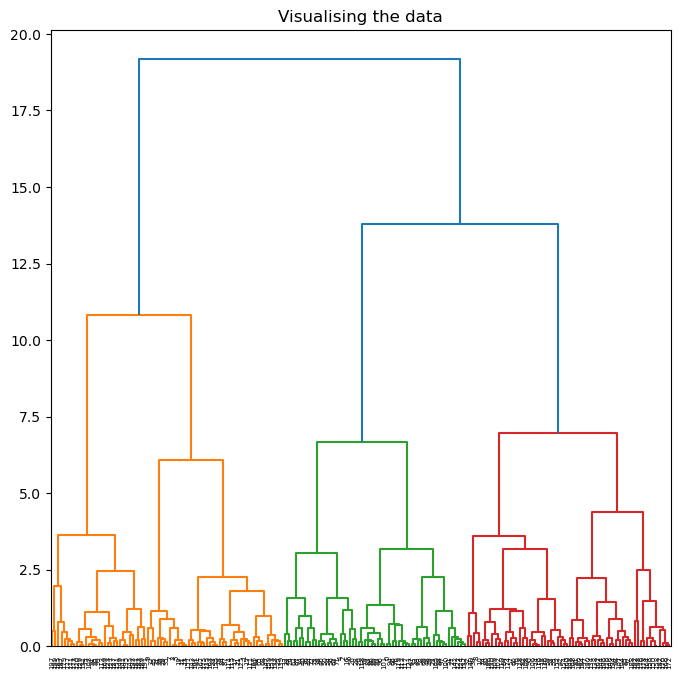

In [29]:
# Data Visualization!

import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering
plt.figure(figsize =(8, 8))
plt.title('Visualising the data')
Dendrogram = shc.dendrogram((shc.linkage(X_principal_5, method ='ward')))

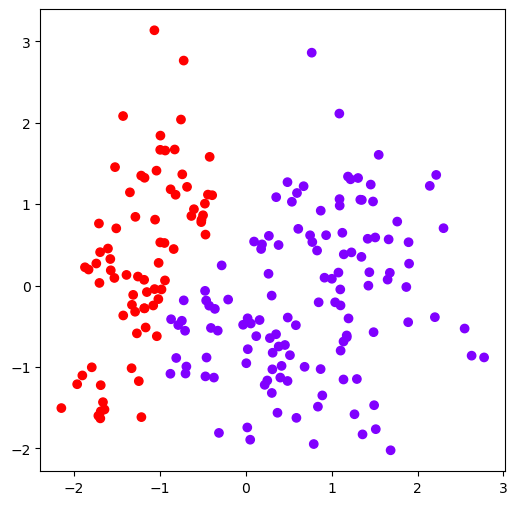

In [31]:
# Building and Visualizing the different clustering models for different values of k

# K=2

ac2 = AgglomerativeClustering(n_clusters = 2)
  
# Visualizing the clustering
plt.figure(figsize =(6, 6))
plt.scatter(X_principal_5['P1'], X_principal_5['P2'], 
           c = ac2.fit_predict(X_principal_5), cmap ='rainbow')
plt.show()

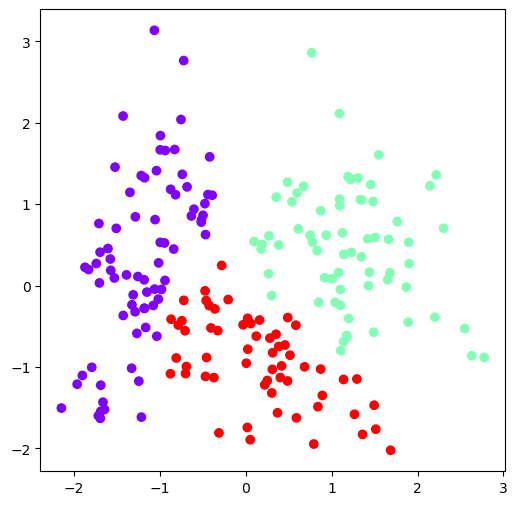

In [32]:
# K=3

ac3 = AgglomerativeClustering(n_clusters = 3)
  
plt.figure(figsize =(6, 6))
plt.scatter(X_principal_5['P1'], X_principal_5['P2'],
           c = ac3.fit_predict(X_principal_5), cmap ='rainbow')
plt.show()

In [35]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

scores = []

for i in range(2, 11):
    agg = AgglomerativeClustering(
        n_clusters=i,
        metric='euclidean',
        linkage='ward'
    )

    labels = agg.fit_predict(X_principal_5)
    score = silhouette_score(X_principal_5, labels)
    scores.append(score)

    print(f"Clusters = {i}, Silhouette Score = {score:.4f}")

Clusters = 2, Silhouette Score = 0.3605
Clusters = 3, Silhouette Score = 0.3616
Clusters = 4, Silhouette Score = 0.3718
Clusters = 5, Silhouette Score = 0.3458
Clusters = 6, Silhouette Score = 0.3417
Clusters = 7, Silhouette Score = 0.3725
Clusters = 8, Silhouette Score = 0.3734
Clusters = 9, Silhouette Score = 0.3603
Clusters = 10, Silhouette Score = 0.3679


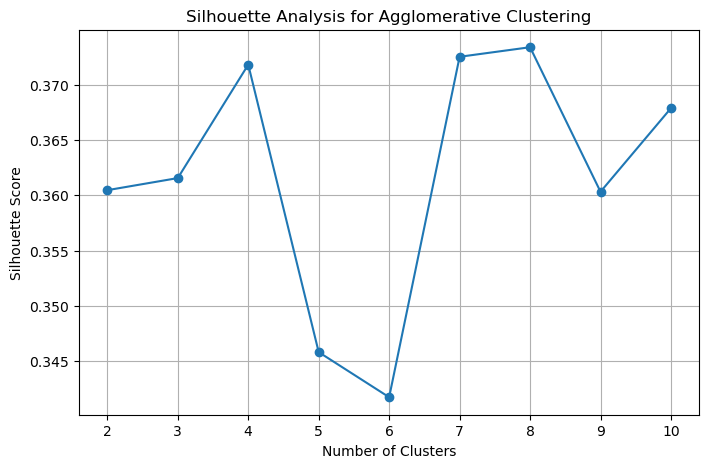

In [36]:
import matplotlib.pyplot as plt

k = range(2, 11)

plt.figure(figsize=(8,5))
plt.plot(k, scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for Agglomerative Clustering")
plt.grid(True)
plt.show()